In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
np.random.seed(42)

data=pd.DataFrame({
    "hours_studied":np.random.randint(1,10,50),
    "attendence":np.random.randint(50,100,50)

})

data.head()

,hours_studied,attendence
0,7,53
1,4,51
2,8,55
3,5,91
4,7,53


In [6]:
x=data[["hours_studied","attendence"]]
model=KMeans(n_clusters=3,random_state=42,n_init=10)
data["cluster"]=model.fit_predict(x)

data.head()

,hours_studied,attendence,cluster
0,7,53,1
1,4,51,1
2,8,55,1
3,5,91,0
4,7,53,1


In [8]:
score=silhouette_score(x,data["cluster"])
print("silhouette Score:",score)


silhouette Score: 0.5276411515754762


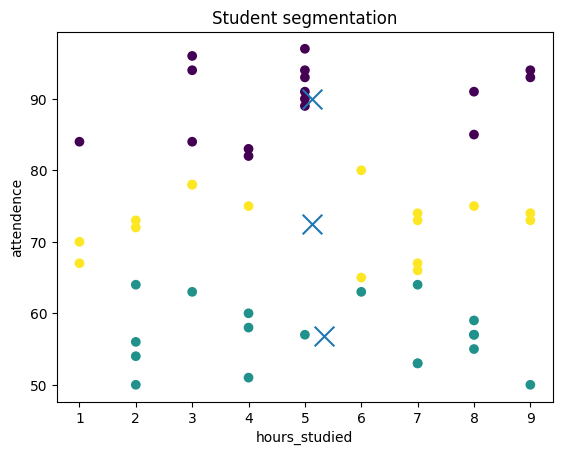

In [9]:
plt.scatter(data["hours_studied"],data["attendence"],c=data["cluster"])
centers=model.cluster_centers_
plt.scatter(centers[:,0],centers[:,1],marker="x",s=200)

plt.xlabel("hours_studied")
plt.ylabel("attendence")
plt.title("Student segmentation")
plt.show()

In [12]:
new_student=[[6,80]]

predicted_cluster=model.predict(new_student)

print("New student belongs to cluster:",predicted_cluster[0])

New student belongs to cluster: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [13]:
data.groupby("cluster").mean()

,hours_studied,attendence
cluster,,
0,5.125000,90.000000
1,5.333333,56.888889
2,5.125000,72.500000
